# Student Performance Predictor — Data Understanding and EDA

This notebook explores the UCI Student Performance dataset (Mathematics course) before modeling. Model training and evaluation are kept in `src/train.py` so this file stays focused on understanding the data.

## 1. Data Understanding

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import load_data, build_features, grade_to_class, FEATURE_COLUMNS, LEAKAGE_COLUMNS

sns.set_theme(style='whitegrid')
df = load_data('../data/student-mat.csv')

print('Shape:', df.shape)
print('\nColumns:', list(df.columns))
print('\nData types:')
print(df.dtypes.value_counts())
print('\nMissing values:', int(df.isnull().sum().sum()))

Shape: (395, 33)

Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Data types:
object    17
int64     16
Name: count, dtype: int64

Missing values: 0


In [2]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## 2. Target Creation and Leakage Check

We create a 3-class target from the final grade `G3` (0-20):
- **Low**: G3 <= 9
- **Medium**: 10 <= G3 <= 13
- **High**: G3 >= 14

The dataset includes `G1` and `G2`, which are earlier period grades in the same course. They are **excluded from modeling** because they are unavailable at prediction time and would leak the final grade.

In [3]:
df['performance'] = df['G3'].map(grade_to_class)
print(df['performance'].value_counts().reindex(['Low', 'Medium', 'High']))
print('\nG1/G2 excluded from modeling:', LEAKAGE_COLUMNS)

performance
Low       130
Medium    165
High      100
Name: count, dtype: int64

G1/G2 excluded from modeling: ['G1', 'G2']


## 3. EDA

### 3.1 Target distribution

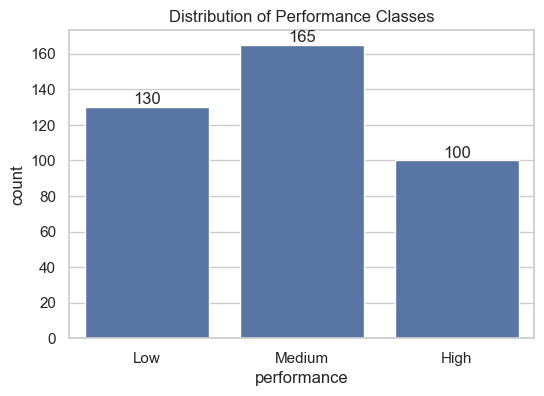

In [4]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='performance', order=['Low', 'Medium', 'High'])
ax.bar_label(ax.containers[0])
plt.title('Distribution of Performance Classes')
plt.show()

### 3.2 Study time vs performance

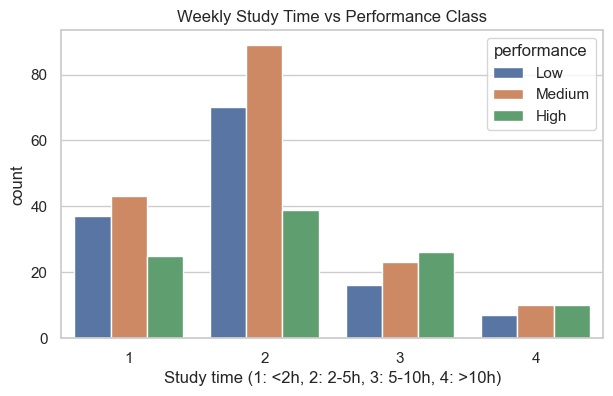

In [5]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='studytime', hue='performance', hue_order=['Low', 'Medium', 'High'])
plt.title('Weekly Study Time vs Performance Class')
plt.xlabel('Study time (1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h)')
plt.show()

### 3.3 Absences vs performance

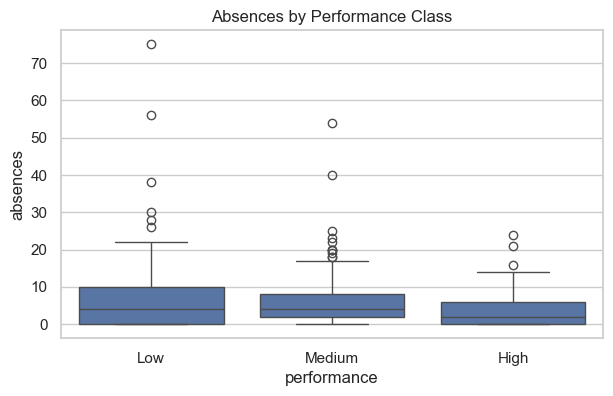

In [6]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='performance', y='absences', order=['Low', 'Medium', 'High'])
plt.title('Absences by Performance Class')
plt.show()

### 3.4 Failures vs performance

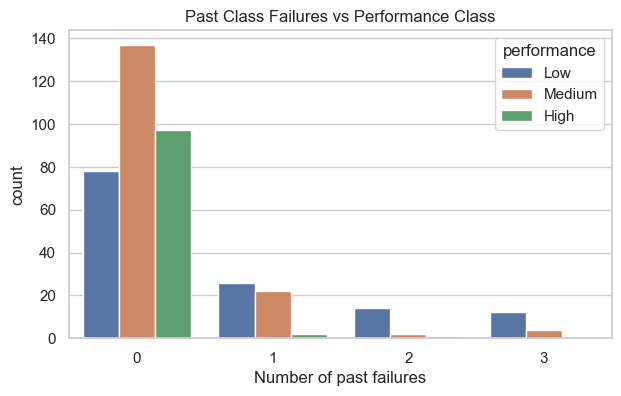

In [7]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='failures', hue='performance', hue_order=['Low', 'Medium', 'High'])
plt.title('Past Class Failures vs Performance Class')
plt.xlabel('Number of past failures')
plt.show()

### 3.5 Correlation heatmap

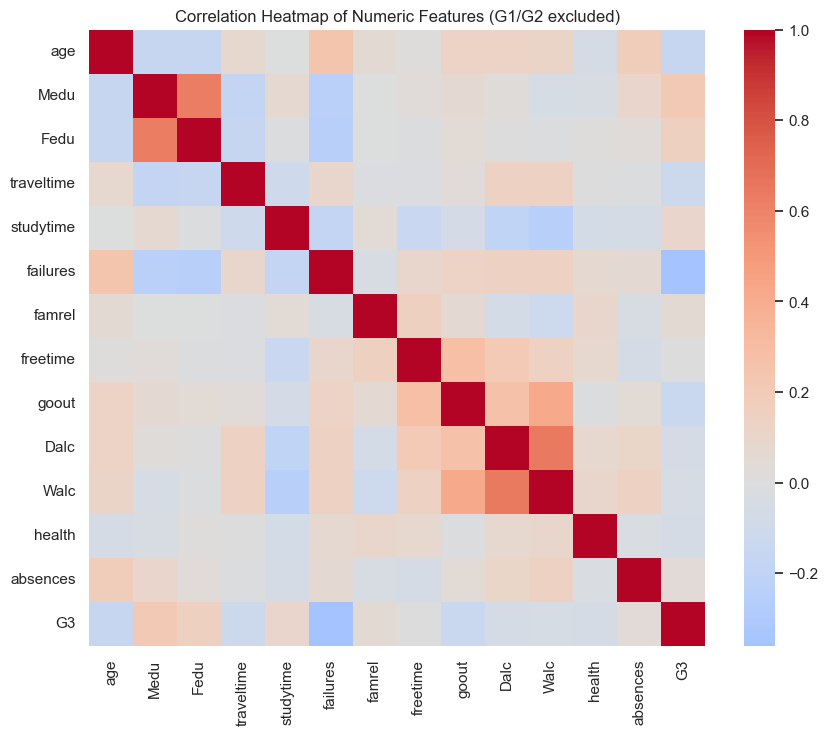

In [8]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include='number').drop(columns=['G1', 'G2'])
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap of Numeric Features (G1/G2 excluded)')
plt.show()

## 4. Feature Set for Modeling

The model will use all non-leaking columns from the dataset, listed below. Preprocessing (imputation, encoding, scaling) is implemented in `src/preprocessing.py` and is only fitted on the training split inside the sklearn pipeline to avoid leakage.

In [9]:
print('Features used for modeling:', FEATURE_COLUMNS)
X, y = build_features(df)
print('\nX shape:', X.shape)
print('y shape:', y.shape)

Features used for modeling: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'Mjob', 'Fjob', 'reason', 'guardian', 'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

X shape: (395, 30)
y shape: (395,)


## 5. Next Steps

Model training, evaluation, and model selection are handled by `src/train.py`. Run it from the project root:

```bash
python -m src.train
```